# Regression of Response: `adj_premium_per_sqft_gfa`

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

# Dataset

In [2]:
df = pd.read_csv("../data/transformation1.csv", header= 0)
df = df.rename(columns={'RGDP(Billions)': "RGDP"})
df.head()

,adj_premium_per_sqft_gfa,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,n_tenderers,award_date,accommodation_value,site_area_sqft,region
0,95.372458,22.333632,114.186290,0.16,267.551886,1,ALS,5.0,2010-03-11,9537.0,75842.4394,Kowloon
1,34.482759,22.500946,114.145969,0.20,267.551886,1,ALS,5.0,2010-05-24,3448.0,95798.7100,New Territories
2,320.135935,22.263681,114.180464,0.18,267.551886,1,govt-led,5.0,2010-07-28,32014.0,250928.0368,Hong Kong Island
3,125.395889,22.311823,114.181960,0.19,267.551886,1,govt-led,5.0,2010-08-06,12540.0,173847.7489,Kowloon
4,103.985696,22.324114,114.185853,0.19,267.551886,1,ALS,5.0,2010-08-17,10399.0,78856.3314,Kowloon


### Preliminary Transformations

In [3]:
df['log_adj_premium_per_sqft_gfa'] = np.log(df['adj_premium_per_sqft_gfa'])
df['log_RGDP'] = np.log(df['RGDP'])
df['log_n_tenderers'] = np.log(df['n_tenderers'])
df['log_accommodation_value'] = np.log(df['accommodation_value'])
df['log_site_area_sqft'] = np.log(df['site_area_sqft'])
df.head()

,adj_premium_per_sqft_gfa,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,n_tenderers,award_date,accommodation_value,site_area_sqft,region,log_adj_premium_per_sqft_gfa,log_RGDP,log_n_tenderers,log_accommodation_value,log_site_area_sqft
0,95.372458,22.333632,114.186290,0.16,267.551886,1,ALS,5.0,2010-03-11,9537.0,75842.4394,Kowloon,4.557790,5.589314,1.609438,9.162934,11.236413
1,34.482759,22.500946,114.145969,0.20,267.551886,1,ALS,5.0,2010-05-24,3448.0,95798.7100,New Territories,3.540459,5.589314,1.609438,8.145550,11.470004
2,320.135935,22.263681,114.180464,0.18,267.551886,1,govt-led,5.0,2010-07-28,32014.0,250928.0368,Hong Kong Island,5.768746,5.589314,1.609438,10.373929,12.432921
3,125.395889,22.311823,114.181960,0.19,267.551886,1,govt-led,5.0,2010-08-06,12540.0,173847.7489,Kowloon,4.831476,5.589314,1.609438,9.436679,12.065935
4,103.985696,22.324114,114.185853,0.19,267.551886,1,ALS,5.0,2010-08-17,10399.0,78856.3314,Kowloon,4.644253,5.589314,1.609438,9.249465,11.275383


In [4]:
print(df.shape)

(157, 17)


In [5]:
cross_tab = pd.crosstab(df['in_als'], df['sale_regime'])
cross_tab.columns.name = None
print(cross_tab)

        ALS  govt-led
in_als               
0         0       101
1         9        47


In [6]:
table = (
    df.groupby(['in_als', 'sale_regime'])['adj_premium_per_sqft_gfa']
      .agg(['mean', 'count'])
)

table

mean  count
in_als sale_regime                   
0      govt-led     862.913802    101
1      ALS          359.383031      9
       govt-led     506.010154     47

### Add New Dummy Variable

In [7]:
df['during_als'] = np.where(df['award_date'] < "2013-02-01", 1, 0)

### Datachecks

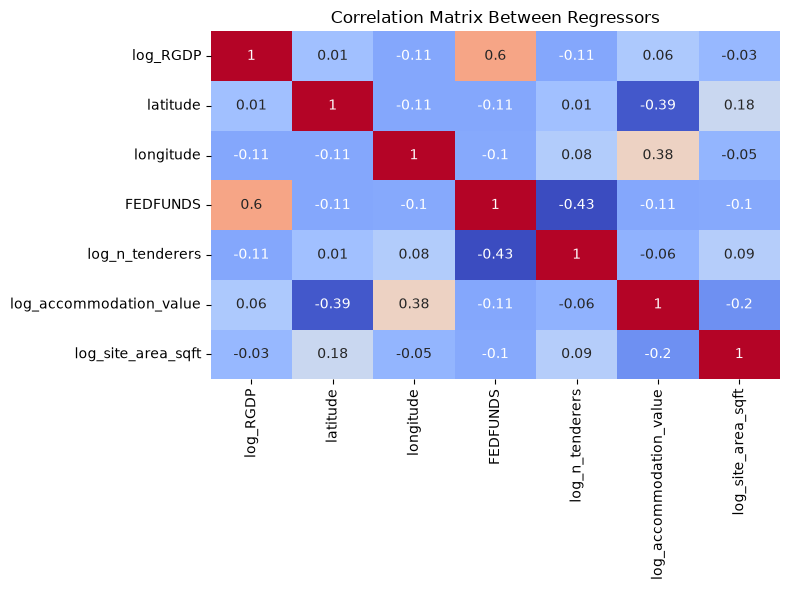

In [8]:
var_corr = ['log_RGDP', 'latitude', 'longitude', 'FEDFUNDS', 'log_n_tenderers', 'log_accommodation_value', 'log_site_area_sqft']
corr = df[var_corr].corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    cbar=False
)
plt.title("Correlation Matrix Between Regressors")
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vars_corr = var_corr + ['in_als', 'during_als']
X = df[vars_corr].copy()
X = sm.add_constant(X)
vif = pd.DataFrame()

vif['Variable'] = X.columns

vif['VIF'] = [variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                  Variable           VIF
0                    const  2.006777e+06
1                 log_RGDP  6.206624e+00
2                 latitude  1.292962e+00
3                longitude  1.231127e+00
4                 FEDFUNDS  2.623072e+00
5          log_n_tenderers  1.488650e+00
6  log_accommodation_value  1.693002e+00
7       log_site_area_sqft  1.076790e+00
8                   in_als  3.534011e+00
9               during_als  3.375561e+00


## Regressions

In [32]:
model1 = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + log_n_tenderers
    """, data=df
).fit()

print(model1.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.809
Model:                                      OLS   Adj. R-squared:                  0.794
Method:                           Least Squares   F-statistic:                     50.99
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           9.93e-46
Time:                                  10:18:31   Log-Likelihood:                -101.12
No. Observations:                           157   AIC:                             228.2
Df Residuals:                               144   BIC:                             268.0
Df Model:                                    12                                         
Covariance Type:                      nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------

|  | ALS | Gvnt-led | 
| :-- | :-- | :-- |

In [33]:
model1b = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    """, data=df
).fit()

print(model1b.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.782
Model:                                      OLS   Adj. R-squared:                  0.769
Method:                           Least Squares   F-statistic:                     58.69
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           3.01e-44
Time:                                  10:18:33   Log-Likelihood:                -111.60
No. Observations:                           157   AIC:                             243.2
Df Residuals:                               147   BIC:                             273.8
Df Model:                                     9                                         
Covariance Type:                      nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [34]:
model1c = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    """, data=df
).fit()

print(model1c.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.794
Model:                                      OLS   Adj. R-squared:                  0.778
Method:                           Least Squares   F-statistic:                     50.70
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           3.88e-44
Time:                                  10:18:35   Log-Likelihood:                -107.39
No. Observations:                           157   AIC:                             238.8
Df Residuals:                               145   BIC:                             275.5
Df Model:                                    11                                         
Covariance Type:                      nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [35]:
model1d = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + log_n_tenderers
    """, data=df
).fit()

print(model1d.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.797
Model:                                      OLS   Adj. R-squared:                  0.783
Method:                           Least Squares   F-statistic:                     57.45
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           1.36e-45
Time:                                  10:18:37   Log-Likelihood:                -105.96
No. Observations:                           157   AIC:                             233.9
Df Residuals:                               146   BIC:                             267.5
Df Model:                                    10                                         
Covariance Type:                      nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [36]:
table = summary_col(
    [model1, model1b, model1c, model1d],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'Without Both', 'Without Tenderers', 'Without Region'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                            Baseline  Without Both Without Tenderers Without Region
-----------------------------------------------------------------------------------
Intercept                 -183.494*** -152.013***  -196.482***       -137.711**    
                          (56.621)    (57.516)     (58.596)          (55.847)      
sale_regime[T.govt-led]   -0.433**    0.005        -0.109            -0.295        
                          (0.216)     (0.201)      (0.202)           (0.215)       
region[T.Kowloon]         -0.330**                 -0.238                          
                          (0.148)                  (0.151)                         
region[T.New Territories] -0.063                   0.069                           
                          (0.182)                  (0.184)                         
latitude                  -1.070      -1.241*      -1.692**          -0.895        
                          (0.734)     (0.639)      (0.738)           (0.627

In [22]:
model2 = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + log_n_tenderers
    + in_als : FEDFUNDS
    + in_als : log_RGDP
    + in_als : log_site_area_sqft
    + in_als : log_accommodation_value
    + in_als : sale_regime
    + in_als : region
    + in_als : log_n_tenderers
    """, data=df    
).fit()

print(model2.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.848
Model:                                      OLS   Adj. R-squared:                  0.827
Method:                           Least Squares   F-statistic:                     40.21
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           1.39e-46
Time:                                  10:09:03   Log-Likelihood:                -83.431
No. Observations:                           157   AIC:                             206.9
Df Residuals:                               137   BIC:                             268.0
Df Model:                                    19                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

In [23]:
model3 = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + log_n_tenderers
    + in_als : sale_regime
    """, data=df    
).fit()

print(model3.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.809
Model:                                      OLS   Adj. R-squared:                  0.794
Method:                           Least Squares   F-statistic:                     50.99
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           9.93e-46
Time:                                  10:09:28   Log-Likelihood:                -101.12
No. Observations:                           157   AIC:                             228.2
Df Residuals:                               144   BIC:                             268.0
Df Model:                                    12                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

|  | ALS | Gvnt-led | 
| :-- | :-- | :-- |
| Not In ALS | Baseline | -46.2544 | 
| In ALS | -45.5973 | 45.8213 - 46.2544 - 45.5973 = -46.0304 | 

In [24]:
model4 = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + n_tenderers
    + in_als : during_als
    """, data=df    
).fit()

print(model4.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.813
Model:                                      OLS   Adj. R-squared:                  0.796
Method:                           Least Squares   F-statistic:                     47.78
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           2.08e-45
Time:                                  10:11:42   Log-Likelihood:                -99.724
No. Observations:                           157   AIC:                             227.4
Df Residuals:                               143   BIC:                             270.2
Df Model:                                    13                                         
Covariance Type:                      nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [25]:
table = summary_col(
    [model1, model2, model3],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'Full Interaction', 'Treatment-Style'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                                   Baseline  Full Interaction Treatment-Style
-----------------------------------------------------------------------------
Intercept                        -183.494*** -127.732***      -137.673***    
                                 (56.621)    (40.301)         (42.471)       
sale_regime[T.govt-led]          -0.433**    -13.191          -46.254***     
                                 (0.216)     (14.592)         (14.176)       
region[T.Kowloon]                -0.330**    0.005            -0.330**       
                                 (0.148)     (0.190)          (0.148)        
region[T.New Territories]        -0.063      0.154            -0.063         
                                 (0.182)     (0.219)          (0.182)        
latitude                         -1.070      -0.919           -1.070         
                                 (0.734)     (0.676)          (0.734)        
longitude                        1.514***    1.326***         1

### Level Regression

In [16]:
model5 = smf.ols(
    """
    adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + RGDP
    + site_area_sqft
    + accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    """, data=df
).fit()

print(model5.summary())

                               OLS Regression Results                               
Dep. Variable:     adj_premium_per_sqft_gfa   R-squared:                       0.783
Model:                                  OLS   Adj. R-squared:                  0.767
Method:                       Least Squares   F-statistic:                     47.62
Date:                      Fri, 28 Aug 2026   Prob (F-statistic):           1.31e-42
Time:                              09:58:51   Log-Likelihood:                -1141.5
No. Observations:                       157   AIC:                             2307.
Df Residuals:                           145   BIC:                             2344.
Df Model:                                11                                         
Covariance Type:                  nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [17]:
model6 = smf.ols(
    """
    adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + RGDP
    + site_area_sqft
    + accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + in_als : FEDFUNDS
    + in_als : RGDP
    + in_als : site_area_sqft
    + in_als : accommodation_value
    + in_als : sale_regime
    + in_als : region
    """, data=df    
).fit()

print(model6.summary())

                               OLS Regression Results                               
Dep. Variable:     adj_premium_per_sqft_gfa   R-squared:                       0.858
Model:                                  OLS   Adj. R-squared:                  0.841
Method:                       Least Squares   F-statistic:                     49.59
Date:                      Fri, 28 Aug 2026   Prob (F-statistic):           2.29e-50
Time:                              10:00:12   Log-Likelihood:                -1108.1
No. Observations:                       157   AIC:                             2252.
Df Residuals:                           139   BIC:                             2307.
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [18]:
model7 = smf.ols(
    """
    adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + RGDP
    + site_area_sqft
    + accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + in_als : sale_regime
    """, data=df    
).fit()

print(model7.summary())

                               OLS Regression Results                               
Dep. Variable:     adj_premium_per_sqft_gfa   R-squared:                       0.783
Model:                                  OLS   Adj. R-squared:                  0.767
Method:                       Least Squares   F-statistic:                     47.62
Date:                      Fri, 28 Aug 2026   Prob (F-statistic):           1.31e-42
Time:                              10:01:28   Log-Likelihood:                -1141.5
No. Observations:                       157   AIC:                             2307.
Df Residuals:                           145   BIC:                             2344.
Df Model:                                11                                         
Covariance Type:                  nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [20]:
table = summary_col(
    [model5, model6, model7],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'Full Interaction', 'Treatment-Style'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                                   Baseline  Full Interaction Treatment-Style
-----------------------------------------------------------------------------
Intercept                        -22562.250  -15737.797       -16943.041     
                                 (41230.361) (25984.565)      (30929.534)    
sale_regime[T.govt-led]          -201.776    -2068.122        -5820.985      
                                 (145.883)   (8694.072)       (10321.675)    
region[T.Kowloon]                -16.135     0.082            -16.135        
                                 (116.817)   (127.393)        (116.817)      
region[T.New Territories]        85.994      -9.326           85.994         
                                 (136.097)   (146.085)        (136.097)      
latitude                         -374.124    55.857           -374.124       
                                 (541.545)   (457.413)        (541.545)      
longitude                        248.000     145.787          2

### Triple Interaction

+ in_als : sale_regime[gvnt-led] : during_als refers to land that are listed in ALS but sold in government led auctions before ALS was abolished 
+ in_als : sale_regime[ALS] : during_als : refers to land that was listed in ALS and sold as ALS before ALS was abolished

In [37]:
model8 = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + log_n_tenderers
    + in_als : sale_regime : during_als
    """, data=df    
).fit()

print(model8.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.813
Model:                                      OLS   Adj. R-squared:                  0.796
Method:                           Least Squares   F-statistic:                     47.72
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           2.23e-45
Time:                                  10:20:37   Log-Likelihood:                -99.799
No. Observations:                           157   AIC:                             227.6
Df Residuals:                               143   BIC:                             270.4
Df Model:                                    13                                         
Covariance Type:                      nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
--

In [38]:
model8b = smf.ols(
    """
    log_adj_premium_per_sqft_gfa ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + log_site_area_sqft
    + log_accommodation_value
    + in_als
    + during_als
    + sale_regime
    + region
    + log_n_tenderers
    + in_als : sale_regime
    + in_als : during_als
    + during_als : sale_regime
    + in_als : sale_regime : during_als
    """, data=df    
).fit()

print(model8b.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_adj_premium_per_sqft_gfa   R-squared:                       0.813
Model:                                      OLS   Adj. R-squared:                  0.796
Method:                           Least Squares   F-statistic:                     47.72
Date:                          Fri, 28 Aug 2026   Prob (F-statistic):           2.23e-45
Time:                                  10:23:49   Log-Likelihood:                -99.799
No. Observations:                           157   AIC:                             227.6
Df Residuals:                               143   BIC:                             270.4
Df Model:                                    13                                         
Covariance Type:                      nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]


In [44]:
cross_tab = pd.crosstab(df['during_als'], df['sale_regime'])
cross_tab.columns.name = None
print(cross_tab)

            ALS  govt-led
during_als               
0             0       117
1             9        31


| Group | Implied Effect | 
| :--- | :--- |
| in als x ALS x during ALS | -62.9525 | 
| in als x ALS x outside ALS | Does not Exist | 
| in als x Gvnt Sale x during ALS | -84.2622 | 
| in als x Gvnt Sale x outside ALS | -62.3181 | 
| not in als x ALS x during ALS | Does not Exist | 
| not in als x ALS x outside ALS | Does Not Exist | 
| not in als x Gvnt Sale x during ALS | -64.3271 | 
| not in als x Gvnt Sale x outside ALS | -62.4645 | 


It suggests that, away from the policy crossover, the two relevant groups have essentially the same predicted premium

In [39]:
table = summary_col(
    [model3, model8, model8b],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'Triple Interaction', 'Full Triple Interaction'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                                            Baseline  Triple Interaction Full Triple Interaction
------------------------------------------------------------------------------------------------
Intercept                                 -137.673*** -110.657***        -104.135***            
                                          (42.471)    (38.329)           (35.901)               
sale_regime[T.govt-led]                   -46.254***  -55.942***         -62.464***             
                                          (14.176)    (19.129)           (21.556)               
region[T.Kowloon]                         -0.330**    -0.322**           -0.322**               
                                          (0.148)     (0.147)            (0.147)                
region[T.New Territories]                 -0.063      -0.052             -0.052                 
                                          (0.182)     (0.181)            (0.181)                
latitude                     